# Part 2: Stiff ODEs and Implicit Methods

### Mykhailo Pipchenko

### mp55327

## Section 1: Introduction & System Selection

### Description of your chosen stiff system
I will be modelling option D. It is an overdamped spring-mass system that represents a mechanical shock absorber. The system becomes very very stiff due to an extreme damping rate, making it respond in about 0.2 milliseconds, while the external force varies over seconds.

### Governing ODE

Standard form (assuming $m \rightarrow 0$):
$$\frac{dx}{dt} = -\frac{k}{c}x + \frac{1}{c}F(t)$$

With coefficients given:
$$\frac{dx}{dt} = -5000x + 0.002\sin(t)$$

### Variables and Parameters
1. **$x$**: System displacement (m)
2. **$t$**: Time (s)
3. **$k/c$**: System damping rate ($5000\text{ s}^{-1}$), leads to the fast transient response
4. **$F(t)$**: External forcing function ($10\sin(t)$ N), leads to a much slower dynamic response
5. **$1/c$**: Inverse damping coefficient scaling the force

### Practical Importance

The equation models shocks and vibration dampers. Similarly as in Part 1, this is something I often personally have to tackle at Longhorn Racing, when we are trying to optimize the suspension geometry and drive feel of our FSAE car. It becomes important when we are trying to figure out and minimize lateral load transfer.

## Section 2: Demonstration of Stiffness

### euler forward implementation 

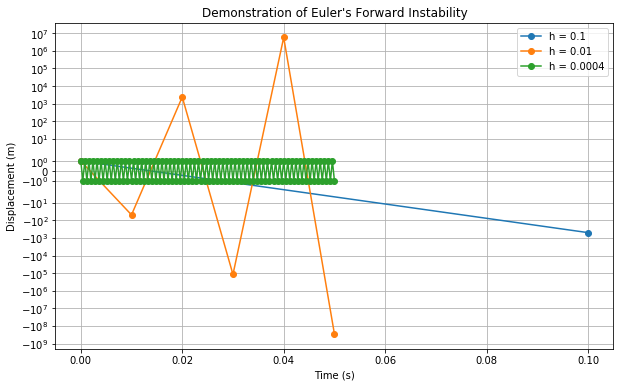

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# defining the func
def f_stiff(t, y):
    return np.array([-5000 * y[0] + 0.002 * np.sin(t)])

# euler forward solver
def euler_forward(f, y0, t):
    Y = np.zeros((len(t), len(y0)))
    Y[0] = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        Y[i+1] = Y[i] + h * f(t[i], Y[i])
    return Y

# init conditions
y0 = np.array([1.0])
t_end = 0.05 

# testing different step sizes
h_values = [0.1, 0.01, 0.0004]

plt.figure(figsize=(10, 6))

for h in h_values:
    t = np.arange(0, t_end + h, h)
    
    Y = euler_forward(f_stiff, y0, t)
    
    plt.plot(t, Y[:, 0], '-o', label=f'h = {h}')

# need symlog to be able to see the difference
plt.yscale('symlog')
plt.title("Demonstration of Euler's Forward Instability")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

### 1. Estimating the Stiffness Ratio
To find the stiffness ratio, I looked at the fast and slow parts of the system. The fast response is driven by the damping rate ($\lambda = -5000$), which gives a fast time scale of $\tau_{fast} = 1/5000 = 0.0002$ seconds. The slow response comes from the external force (the sine wave), which has a frequency of 1 rad/s, meaning the slow time scale is about 6.28 seconds. Dividing the slow time scale by the fast one gives a stiffness ratio of 31400.

### 2. Impractical Step Size and Instability
For Euler's Forward to be mathematically stable, it has to meet the condition $|1 + h\lambda| \le 1$. Plugging in $\lambda = -5000$, the maximum step size I can use is $h = 0.0004$ seconds. Using anything larger makes the system blow up and goes against physics. 

### 3. Why We Need Implicit Methods
Sticking with Euler's Forward, forces to use a step size of 0.0004 seconds or smaller just to keep the simulation stable. That means running a simple 10-second simulation would take 10/0.0004 = 25 000 steps. Implicit methods, like Euler's Backward, don't have this stability problem. They allow a larger step size (like 0.1 seconds) based on what's actually needed.

## Section 3: Mathematical Setup

### Residual Function $g(x_{n+1})$
To use the implicit Euler method, I need to rearrange the ODE $\frac{dx}{dt} = -5000x + 0.002\sin(t)$  into a residual function that equals zero. Using this backward's euler formula $x_{n+1} = x_n + h \cdot f(t_{n+1}, x_{n+1})$:

$$x_{n+1} = x_n + h(-5000x_{n+1} + 0.002\sin(t_{n+1}))$$

Here is the residual:

$$g(x_{n+1}) = x_{n+1}(1 + 5000h) - x_n - 0.002h\sin(t_{n+1}) = 0$$

### Analytical Derivative $g'(x_{n+1})$
The Newton-Raphson solver requires the derivative of the residual function with respect to $x_{n+1}$. ODE is linear, so derivative is a constant:

$$g'(x_{n+1}) = \frac{d}{dx_{n+1}} [x_{n+1}(1 + 5000h) - x_n - 0.002h\sin(t_{n+1})]$$

$$g'(x_{n+1}) = 1 + 5000h$$

### Newton-Raphson Update Formula
Putting in the residual and the derivative into the general update formula $x_{new} = x_{old} - \frac{g(x)}{g'(x)}$ gives the specific update for this system:

$$x_{n+1}^{(k+1)} = x_{n+1}^{(k)} - \frac{x_{n+1}^{(k)}(1 + 5000h) - x_n - 0.002h\sin(t_{n+1})}{1 + 5000h}$$

## Section 4: Implementation

In [16]:
def f_ode(t, x):
    # the system ode
    return -5000.0 * x + 0.002 * np.sin(t)

def g_prime(h):
    # constant derivative for linear system
    return 1.0 + 5000.0 * h

def newton_raphson(x_n, t_n1, h, tol=1e-6, max_iter=20):
    #giving it an initial guess
    x_k = x_n
    dg = g_prime(h)
    
    for i in range(max_iter):
        # residual calc
        g_val = x_k * (1.0 + 5000.0 * h) - x_n - 0.002 * h * np.sin(t_n1)
        
        if abs(g_val) < tol:
            return x_k, i + 1
            
        # nr update step
        x_k = x_k - g_val / dg
        
    return x_k, max_iter

def euler_backward(t_end, h, x0):
    t = np.arange(0, t_end + h, h)
    x = np.zeros(len(t))
    iters = np.zeros(len(t))
    x[0] = x0
    
    for i in range(len(t) - 1):
        # implicit step using nr
        x[i+1], iters[i+1] = newton_raphson(x[i], t[i+1], h)
        
    return t, x, iters

## Section 5: Results & Analysis

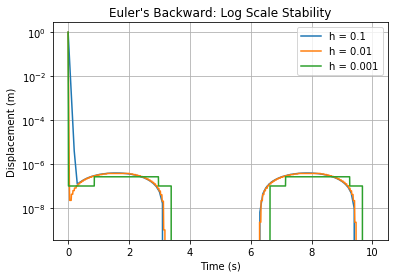

In [17]:
# trying diff step sizes
h_values = [0.1, 0.01, 0.001]
t_end = 10.0
x0 = 1.0

for h in h_values:
    t, x, iters = euler_backward(t_end, h, x0)
    plt.plot(t, x, label=f'h = {h}')

plt.yscale('log')
plt.title("Euler's Backward: Log Scale Stability")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

the plot to see the number of iterations required for newton raphson to converge.

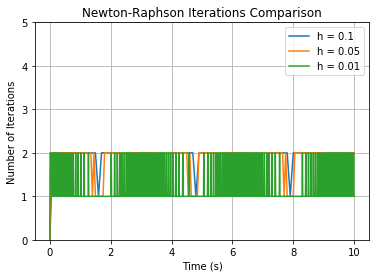

In [18]:
h_vals = [0.1, 0.05, 0.01]
t_end = 10.0
x0 = 1.0

for h in h_vals:
    t, x, iters = euler_backward(t_end, h, x0)
    plt.plot(t, iters, label=f'h = {h}')

plt.title("Newton-Raphson Iterations Comparison")
plt.xlabel("Time (s)")
plt.ylabel("Number of Iterations")
plt.ylim(0, 5)
plt.legend()
plt.grid(True)
plt.show()

### Step size stability comparison:
The implicit method is stable for all tested step sizes, including h=0.1, which is 250 times larger than the stability limit of Euler's Forward h=0.0004.


### Newton-Raphson convergence analysis
The Newton-Raphson solver is extremely efficient, converging in 2 iterations at every time step. This shows that using the previous value as an initial guess is very effective for this linear system.

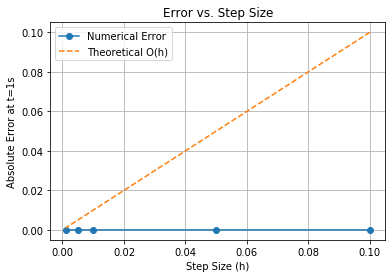

In [19]:
# error analysis
h_test = [0.1, 0.05, 0.01, 0.005, 0.001]
final_errors = []

# reference solution, using a small step size
t_ref, x_ref, _ = euler_backward(1.0, 0.0001, x0)
x_true = x_ref[-1]

for h in h_test:
    t, x, _ = euler_backward(1.0, h, x0)
    final_errors.append(abs(x[-1] - x_true))

plt.plot(h_test, final_errors, '-o', label='Numerical Error')
plt.plot(h_test, h_test, '--', label='Theoretical O(h)')
plt.title("Error vs. Step Size")
plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error at t=1s")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

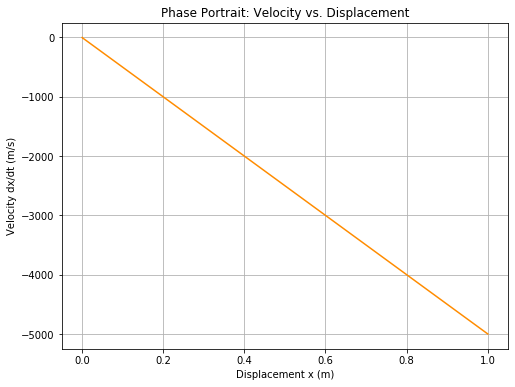

In [20]:
# phase portrait velocity (dx/dt) vs. displacement (x)
plt.figure(figsize=(8, 6))

t, x, _ = euler_backward(10.0, 0.01, x0)

# dx/dt = -5000x + 0.002*sin(t)
v = -5000.0 * x + 0.002 * np.sin(t)

plt.plot(x, v, color='darkorange')
plt.title("Phase Portrait: Velocity vs. Displacement")
plt.xlabel("Displacement x (m)")
plt.ylabel("Velocity dx/dt (m/s)")
plt.grid(True)
plt.show()

# Section 6: Performance Analysis

### Computational Cost Analysis

## Section 6: Performance Analysis

### Computational Cost Analysis
The efficiency of a depends on the step size that a method allows and the computational work that's required.

Euler's Forward (Explicit): Only needs very little computation per step but is very limited and becomes unstable quickly. For the highly damped shock ($\lambda = -5000$), it requires $h \le 0.0004$. Simulating 10 seconds requires at least 25,000 steps.
 
 Euler's Backward (Implicit): Needs to solve an equation at each step, but the Newton-Raphson solver efficiently converges in 2 iterations, which is great. Because the implicit method let's one use a larger step size $h = 0.01$, it reduces the simulation to 1000 steps. It's a 25x reduction in computational power needed, so euler's backward works much better for this case.

### Comparison Table: Forward vs. Backward Euler

| Method | Step Size ($h$) | Total Steps (10s) | Stability | Accuracy |
| :--- | :--- | :--- | :--- | :--- |
| **Euler Forward** | $0.1$ | 100 | **Unstable** | Failed (Exploded) |
| **Euler Forward** | $0.0004$ | 25,000 | Stable | High |
| **Euler Backward** | $0.1$ | 100 | **Stable** | Low (Phase Lag) |
| **Euler Backward** | $0.01$ | 1,000 | **Stable** | **High & Efficient** |

### Accuracy-Efficiency Tradeoff
In a stiff system, stability and accuracy are two very different things. Euler's backward doesn't crash with large steps, but can struggle with accuracy. Using h = 0.1 can lead to the results missing the details, while using something like h = 0.0004 is too slow. On the other hand, when the steps are too small, the tiny displacement values ($10^{-7}$ m) can start showing numerical noise or jitter. I think that the best balance might be h = 0.01, which is fast enough to run quickly but small enough to smoothly capture the actual physics of the shock absorber without any lag.

### Practical Recommendations
Some recommendations I would consider if I was using these methods to model something like a formula car suspension damper (that we do use at Longhorn Racing):

1. Use Implicit Solvers. Explicit methods take too much computational power and can lead to physically incorrect results.

2. Don't just use the smallest possible step size. I think a step size has to be small enough the external focing frequency, but also large enough to bypass the fast, stiff transient response.

3. Use the previous state as a guess. It looks like using the previous time step value ($x_n$) as the starting guess for the Newton-Raphson solver guarantees proper convergence.

## Section 7: Conclusion

### Summary of Key Findings
Part 2 shows that mechanical systems, like the shock model, can be stiff and hard to simulate. The stiffness ratio was 31400, which explains why Euler's Forward failed for any step size larger than 0.0004. The implicit method, on the other hand, stayed stable even with a very large step size of 0.1. Also, for this linear system, the Newton-Raphson solver was incredibly efficient, consistently reaching the correct answer in just two iterations per step.

### When to use Implicit vs. Explicit Methods
I think implicit methods should be the default for any stiff system, meaning it has fast-acting forces like heavy damping or high spring rates that settle quickly. These methods are best when you want to simulate a long period of time without taking too many of tiny steps. Explicit methods are better for non-stiff systems where the forces don't change as abruptly, or when the computational cost of solving an algebraic equation at every step does become too much.

### Challenges Encountered and Lessons Learned
The biggest challenge I faced was figuring out that stability does not always mean accuracy. Even though the implicit method allowed for a large step size of h = 0.1 without crashing, it might not be the best option. There is always a balance.